# 02 · Train single-object ID models

| Model | Initialization |
|---|---|
| SimpleCNN | from scratch (baseline) |
| ResNet18 | ImageNet, fine-tuned |
| MobileNetV3-Large | ImageNet, fine-tuned |
| EfficientNet-B0 | ImageNet, fine-tuned |

AdamW (wd 1e-4) with cosine LR, cross-entropy with label smoothing 0.1, batch 32, early stopping after 6 epochs without val improvement. The best-val checkpoint is scored once on the test set.

Checkpoints go to `models/<Model>.pt`; metrics, curves and confusion matrices to `results/<Model>_*`. Models with existing results are skipped unless `RETRAIN = True`.

In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd
import torch

from classifier.compare import load_report
from classifier.data import build_loaders, denormalize, load_split, pick_device, train_transform
from classifier.models import DEFAULTS, MODEL_NAMES, build_model, count_params
from classifier.train import train_model

RESULTS = ROOT / "results"
MODELS = ROOT / "models"
RETRAIN = False
BATCH_SIZE = 32
PATIENCE = 6
SEED = 42
NUM_WORKERS = 0 if sys.platform == "darwin" else 2

device = pick_device()
split = load_split(ROOT / "data")
loaders, classes = build_loaders(split, BATCH_SIZE, NUM_WORKERS)
print(f"device {device} | torch {torch.__version__} | {len(classes)} classes |", split.groupby("split").size().to_dict())

device mps | torch 2.14.1 | 38 classes | {'test': 535, 'train': 2549, 'val': 535}


## Augmentation

Random resized crop (70–100%), horizontal flip, ±15° rotation, color jitter. Val/test images are only resized. All inputs use ImageNet normalization.

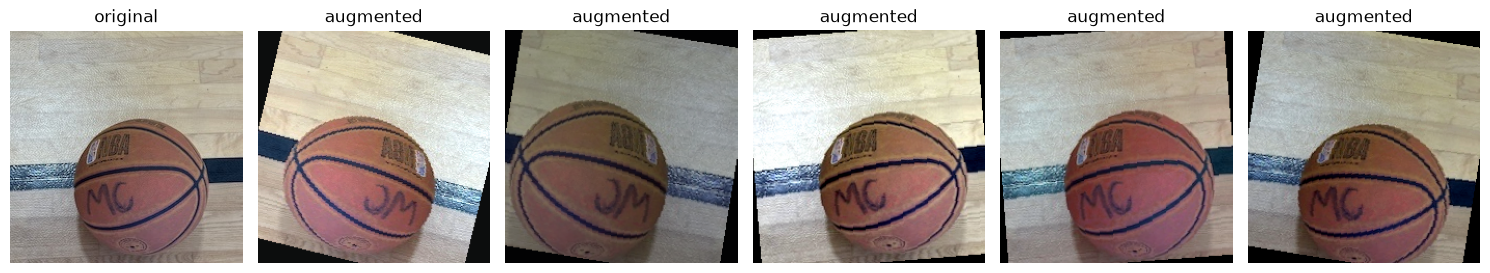

In [2]:
img = loaders["train"].dataset.images[0]
fig, axes = plt.subplots(1, 6, figsize=(15, 2.8))
axes[0].imshow(img); axes[0].set_title("original")
for ax in axes[1:]:
    ax.imshow(denormalize(train_transform()(img))); ax.set_title("augmented")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

## Models

In [3]:
pd.DataFrame([{"model": n, "params (M)": round(count_params(build_model(n, len(classes), pretrained=False)) / 1e6, 2),
               "pretrained": n != "SimpleCNN", **DEFAULTS[n]} for n in MODEL_NAMES])

,model,params (M),pretrained,lr,epochs
0,SimpleCNN,1.18,False,0.0010,40
1,ResNet18,11.20,True,0.0003,15
2,MobileNetV3,4.25,True,0.0003,15
3,EfficientNetB0,4.06,True,0.0003,15


## Train

In [4]:
for name in MODEL_NAMES:
    if not RETRAIN and (MODELS / f"{name}.pt").exists() and (RESULTS / f"{name}_classification_report.json").exists():
        print(f"{name}: already trained, skipping")
        continue
    train_model(name, loaders, classes, device, MODELS, RESULTS, patience=PATIENCE, seed=SEED)

SimpleCNN: already trained, skipping
ResNet18: already trained, skipping
MobileNetV3: already trained, skipping
EfficientNetB0: already trained, skipping


## Training curves

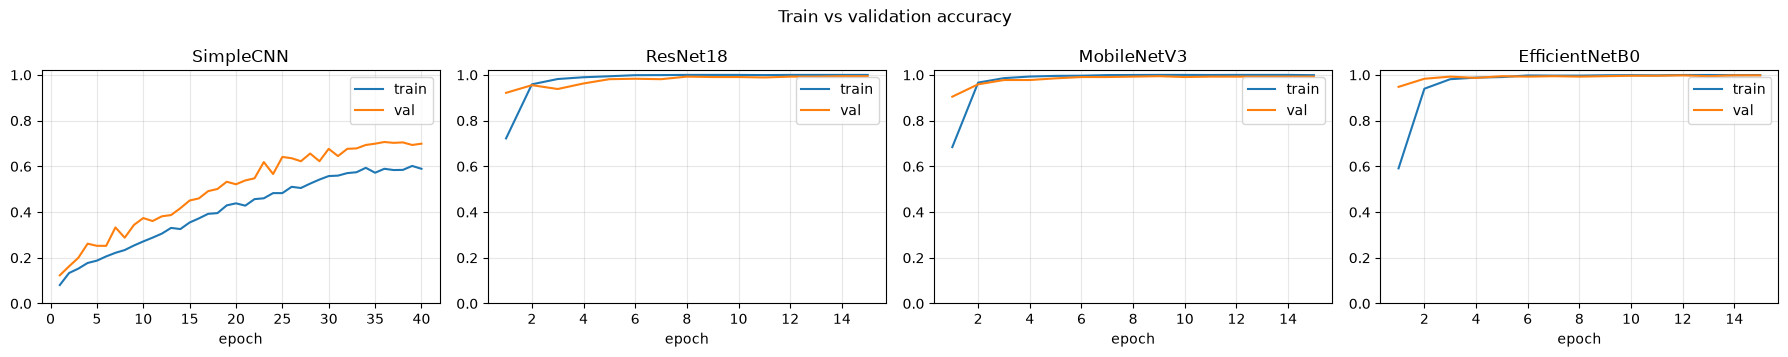

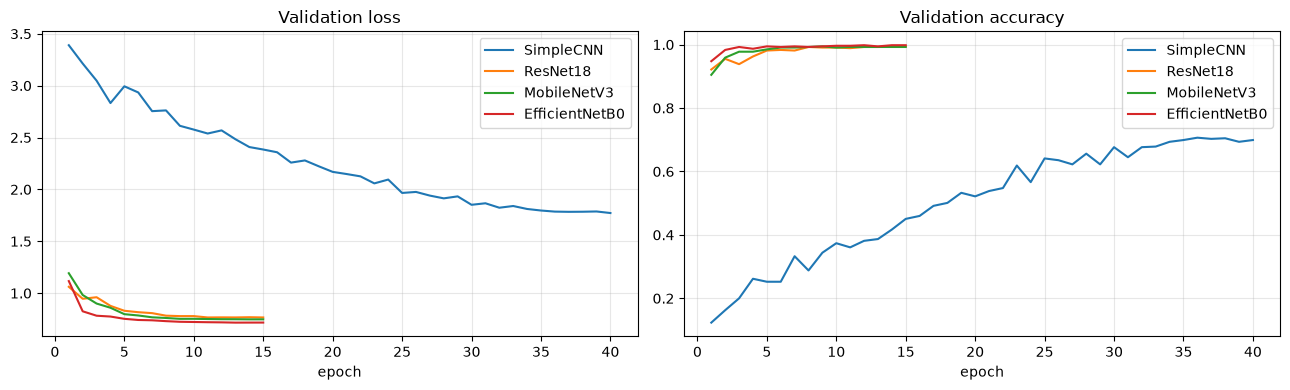

In [5]:
history = {name: pd.DataFrame(load_report(RESULTS, name)["history"]) for name in MODEL_NAMES}

fig, axes = plt.subplots(1, len(history), figsize=(18, 3.6))
for ax, (name, h) in zip(axes, history.items()):
    ax.plot(h.epoch, h.train_acc, label="train"); ax.plot(h.epoch, h.val_acc, label="val")
    ax.set_title(name); ax.set_ylim(0, 1.02); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Train vs validation accuracy"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, h in history.items():
    axes[0].plot(h.epoch, h.val_loss, label=name); axes[1].plot(h.epoch, h.val_acc, label=name)
axes[0].set_title("Validation loss"); axes[1].set_title("Validation accuracy")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()